# 6.1 Predicción del Clima con RNN y LSTM

Este notebook demuestra la predicción de temperatura diaria para **Cartagena, Colombia** usando dos arquitecturas de redes recurrentes: **SimpleRNN** y **LSTM**.

Los datos se obtienen automáticamente desde **Meteostat** (estaciones meteorológicas reales).

*Basado en el notebook de Farrukh Qureshi — Assistant Professor at Namal University Mianwali.*

## Objetivo

- Obtener y preprocesar datos meteorológicos reales de una serie temporal.
- Construir y comparar modelos **SimpleRNN** y **LSTM** para predicción de temperatura.
- Evaluar el desempeño con métricas MSE, RMSE y MAE.
- Generar predicciones futuras usando los modelos entrenados.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado el [notebook 06 (RNN/LSTM intro)](./06_redes_recurrentes_rnn_lstm.ipynb).

- Conceptos de redes recurrentes, LSTM y series temporales.
- Manejo básico de pandas para series de tiempo.

In [ ]:
#!pip install meteostat -qqq

In [ ]:
# === Reproducibilidad y supresión de logs ===
import os
import random
import logging
import warnings

# Suprimir logs TF/XLA ANTES de importar TF (ver buenas prácticas en NB05)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import date, timedelta
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import meteostat as ms
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Segunda capa: suprimir logs a nivel Python
tf.get_logger().setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

%matplotlib inline
print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.21.0
GPU disponible: False


## 1. Obtención de datos

Usamos **Meteostat** para descargar datos meteorológicos históricos diarios de Cartagena.

La variable objetivo es `tavg` (temperatura promedio diaria en °C).
Meteostat puede tener días sin datos; se rellena con `ffill()` (forward fill: propaga el último valor conocido hacia adelante).

In [2]:
# Coordenadas de Cartagena, Colombia
latitude  = 10.3943121
longitude = -75.4789874

POINT = ms.Point(latitude,longitude, 113)
START = date(2020, 1, 1)
END = date(2025, 3, 11)

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)

# Get daily data & perform interpolation
ts = ms.daily(stations, START, END)
data = ms.interpolate(ts, POINT).fetch()

In [13]:
data.head()

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc
time,,,,,,,,
2020-01-01,28.1,25.7,32.3,76,<NA>,13.0,1009.9,<NA>
2020-01-02,27.4,23.9,32.3,80,0.0,11.8,1010.3,<NA>
2020-01-03,27.0,23.5,31.5,81,<NA>,11.0,1011.7,<NA>
2020-01-04,26.6,22.7,30.3,84,0.0,11.1,1012.8,<NA>
2020-01-05,27.9,23.2,32.3,75,0.0,17.9,1013.6,<NA>


Rango: 2020-01-01 → 2025-03-11
Total días: 1897
Valores nulos en tavg: 0


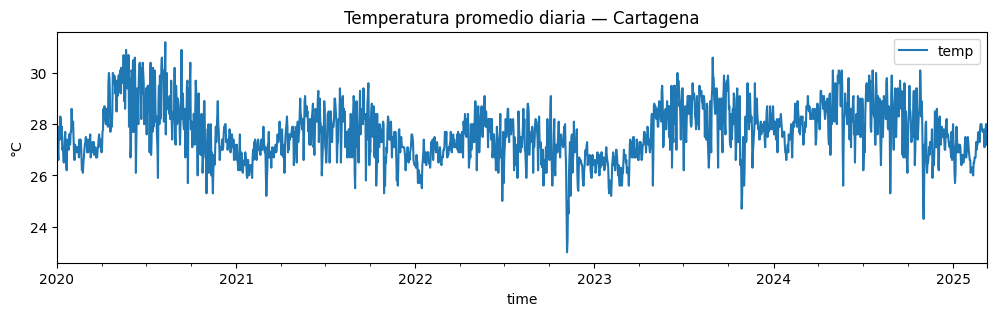

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc
time,,,,,,,,
2020-01-01,28.1,25.7,32.3,76,<NA>,13.0,1009.9,<NA>
2020-01-02,27.4,23.9,32.3,80,0.0,11.8,1010.3,<NA>
2020-01-03,27.0,23.5,31.5,81,<NA>,11.0,1011.7,<NA>
2020-01-04,26.6,22.7,30.3,84,0.0,11.1,1012.8,<NA>
2020-01-05,27.9,23.2,32.3,75,0.0,17.9,1013.6,<NA>


In [4]:
print(f'Rango: {data.index.min().date()} → {data.index.max().date()}')
print(f'Total días: {len(data)}')
print(f'Valores nulos en tavg: {data["temp"].isna().sum()}')
data[['temp']].plot(figsize=(12, 3), title='Temperatura promedio diaria — Cartagena', ylabel='°C')
plt.show()
data.head()

## 2. Preprocesamiento

### Pasos:
1. **Rellenar valores faltantes** con `ffill()` — propaga el último valor conocido.
2. **Escalar** con `MinMaxScaler` al rango `[0, 1]`. Las RNN/LSTM son sensibles a la magnitud de los valores; escalar estabiliza el gradiente y acelera la convergencia.
3. **Crear secuencias** de longitud `sequence_length=30`: cada muestra es una ventana de 30 días consecutivos y el target es el día siguiente.
4. **Dividir** en train y test: los últimos 30 días para evaluación.

> **¿Por qué `MinMaxScaler` y no `StandardScaler`?**  
> Las activaciones `tanh` y `sigmoid` de RNN/LSTM tienen rango `[-1, 1]` y `[0, 1]` respectivamente. Escalar a `[0, 1]` evita saturación de las activaciones desde el primer paso.

In [5]:
# Seleccionar temperatura promedio y rellenar faltantes
df = data[['temp']].copy()
df = df.ffill().bfill()  # ffill primero, bfill por si hay NaN al inicio

# Escalar a [0, 1]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Crear secuencias deslizantes (ventana de 30 días → predecir día 31)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])      # ventana de entrada
        y.append(data[i + seq_length, 0])           # valor a predecir
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 30
X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)

# Últimos 30 días para test
train_size = len(X) - 30
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape: (samples, timesteps, features=1) — requerido por LSTM/RNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (1837, 30, 1)  y_train: (1837,)
X_test:  (30, 30, 1)   y_test:  (30,)


## 3. Construcción y entrenamiento

Comparamos dos arquitecturas recurrentes:

| Modelo | Descripción | Ventaja |
|--------|------------|--------|
| **SimpleRNN** | Celda recurrente básica: `h_t = tanh(W·x_t + U·h_{t-1} + b)` | Simple, rápido |
| **LSTM** | Agrega puertas de olvido, entrada y salida para controlar el flujo de información | Captura dependencias largas, más robusto al gradiente evanescente |

Ambos modelos usan:
- **50 unidades** recurrentes — balance entre capacidad y riesgo de sobreajuste.
- **Adam** con `lr=0.001` — optimizador adaptativo estándar para RNN.
- **EarlyStopping** sobre `val_loss` — detiene antes de sobreajustar y restaura los mejores pesos.
- **`validation_split=0.1`** — reserva el 10% final del train para monitorear generalización.

In [6]:
def create_rnn_model(seq_len):
    model = Sequential([
        Input(shape=(seq_len, 1)),       # entrada explícita — API moderna Keras 3
        SimpleRNN(50, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def create_lstm_model(seq_len):
    model = Sequential([
        Input(shape=(seq_len, 1)),
        LSTM(50),                        # LSTM tiene tanh + sigmoid internamente
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

rnn_model  = create_rnn_model(SEQUENCE_LENGTH)
lstm_model = create_lstm_model(SEQUENCE_LENGTH)

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print('Entrenando RNN...')
rnn_history = rnn_model.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_split=0.1, callbacks=[es], verbose=0
)

print(f'RNN detenido en época {len(rnn_history.history["loss"])}')

print('Entrenando LSTM...')
lstm_history = lstm_model.fit(
    X_train, y_train, epochs=50, batch_size=32,
    validation_split=0.1, callbacks=[es], verbose=0
)

print(f'LSTM detenido en época {len(lstm_history.history["loss"])}')

Entrenando RNN...
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 3.
RNN detenido en época 8
Entrenando LSTM...
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
LSTM detenido en época 5


## 4. Curvas de entrenamiento

Comprobamos que ambos modelos convergieron sin sobreajuste (train_loss y val_loss deben bajar juntas y mantenerse próximas).

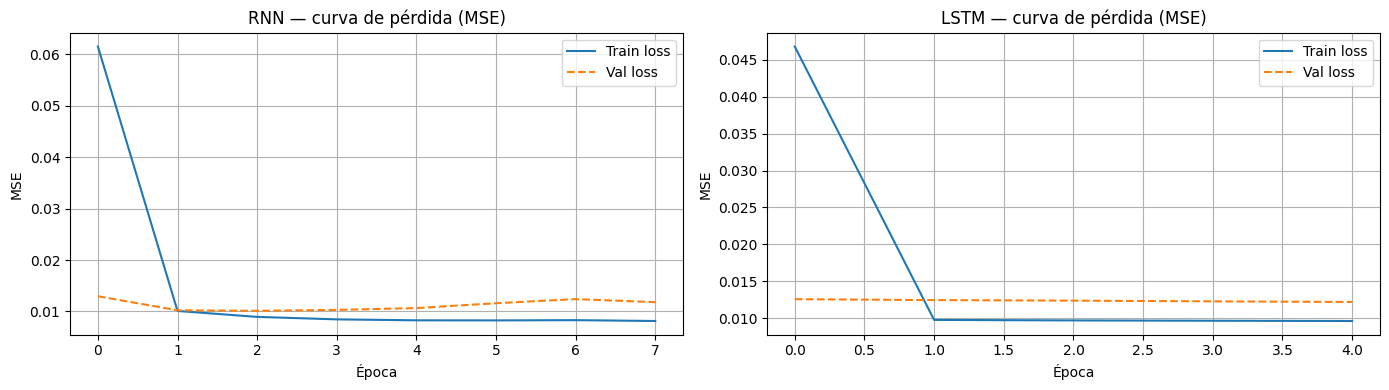

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, name in zip(axes,
                              [rnn_history, lstm_history],
                              ['RNN', 'LSTM']):
    ax.plot(history.history['loss'],     label='Train loss')
    ax.plot(history.history['val_loss'], label='Val loss', linestyle='--')
    ax.set_title(f'{name} — curva de pérdida (MSE)')
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluación en el conjunto de prueba

**Métricas usadas:**
- **MSE** (Mean Squared Error): penaliza errores grandes. Útil para detectar outliers.
- **RMSE** (Root MSE): en las mismas unidades que la variable (°C). Más interpretable.
- **MAE** (Mean Absolute Error): error promedio en °C, menos sensible a outliers que RMSE.

In [8]:
# Predicciones en escala normalizada
rnn_pred_scaled  = rnn_model.predict(X_test,  verbose=0)
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)

# Desnormalizar — reshape(-1,1) garantiza la forma correcta para inverse_transform
rnn_pred  = scaler.inverse_transform(rnn_pred_scaled)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

def calculate_metrics(actual, predicted):
    mse  = np.mean((actual - predicted) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(actual - predicted))
    return mse, rmse, mae

rnn_mse,  rnn_rmse,  rnn_mae  = calculate_metrics(y_test_actual, rnn_pred)
lstm_mse, lstm_rmse, lstm_mae = calculate_metrics(y_test_actual, lstm_pred)

results = pd.DataFrame({
    'MSE':  [rnn_mse,  lstm_mse],
    'RMSE': [rnn_rmse, lstm_rmse],
    'MAE':  [rnn_mae,  lstm_mae],
}, index=['RNN', 'LSTM'])

print(results.round(4))

         MSE    RMSE     MAE
RNN   0.1264  0.3555  0.2848
LSTM  0.1733  0.4163  0.3404


## 6. Visualización de predicciones

Comparamos los valores reales contra las predicciones de ambos modelos en los últimos 30 días.

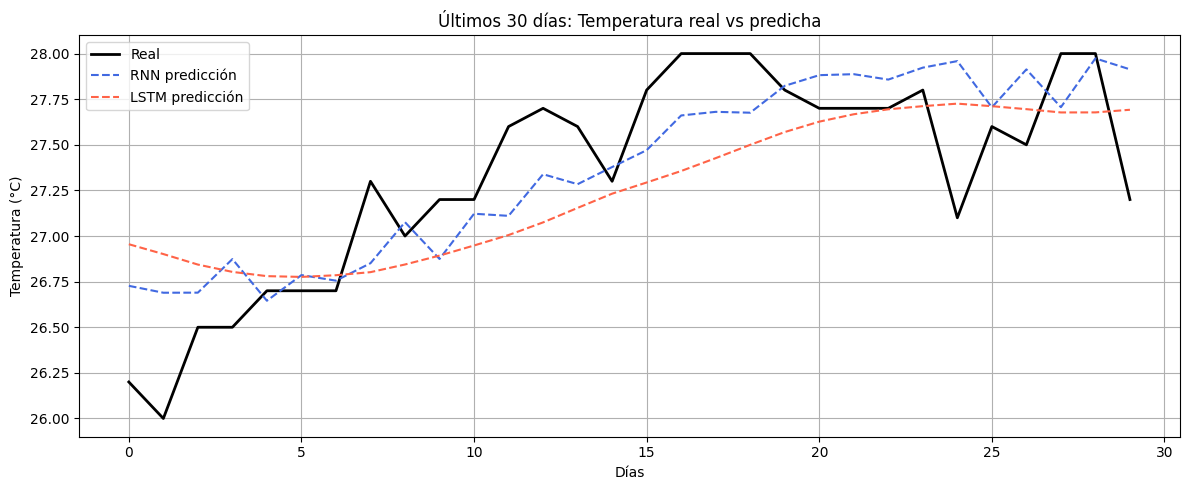

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Real',            color='black', linewidth=2)
plt.plot(rnn_pred,      label='RNN predicción',  color='royalblue', linestyle='--')
plt.plot(lstm_pred,     label='LSTM predicción', color='tomato',    linestyle='--')
plt.title('Últimos 30 días: Temperatura real vs predicha')
plt.xlabel('Días')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Predicciones futuras (próximos 5 días)

Usamos la última secuencia conocida para predecir de forma **autoregresiva**: cada predicción se convierte en el input de la siguiente.

> **Nota:** RNN y LSTM mantienen secuencias **independientes** para que las predicciones de un modelo no contaminen al otro.

Predicciones para los próximos 5 días (°C):
              RNN       LSTM
Día +1  27.680000  27.690001
Día +2  27.980000  27.680000
Día +3  27.870001  27.670000
Día +4  27.900000  27.670000
Día +5  27.920000  27.670000


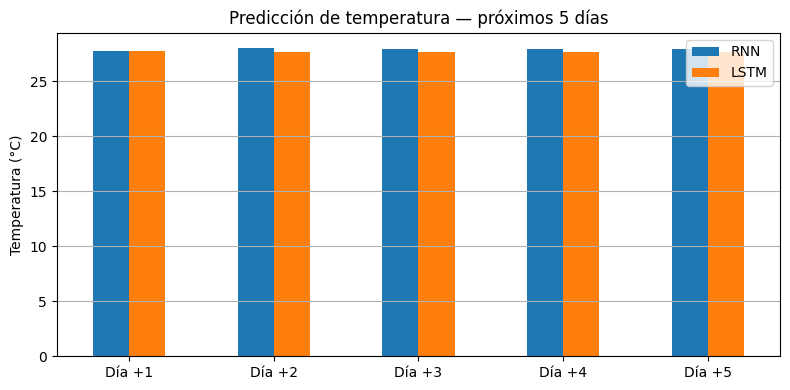

In [10]:
FUTURE_DAYS = 5

# Secuencias iniciales INDEPENDIENTES para cada modelo
seq_rnn  = scaled_data[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1).copy()
seq_lstm = scaled_data[-SEQUENCE_LENGTH:].reshape(1, SEQUENCE_LENGTH, 1).copy()

future_rnn  = []
future_lstm = []

for _ in range(FUTURE_DAYS):
    # Predicción RNN
    rnn_next  = rnn_model.predict(seq_rnn,   verbose=0)
    future_rnn.append(rnn_next[0, 0])
    # Desplazar ventana RNN con su propia predicción
    seq_rnn = np.roll(seq_rnn, -1, axis=1)
    seq_rnn[0, -1, 0] = rnn_next[0, 0]

    # Predicción LSTM
    lstm_next = lstm_model.predict(seq_lstm, verbose=0)
    future_lstm.append(lstm_next[0, 0])
    # Desplazar ventana LSTM con su propia predicción
    seq_lstm = np.roll(seq_lstm, -1, axis=1)
    seq_lstm[0, -1, 0] = lstm_next[0, 0]

# Desnormalizar
future_rnn  = scaler.inverse_transform(np.array(future_rnn).reshape(-1, 1))
future_lstm = scaler.inverse_transform(np.array(future_lstm).reshape(-1, 1))

print('Predicciones para los próximos 5 días (°C):')
future_df = pd.DataFrame({
    'RNN':  future_rnn.flatten(),
    'LSTM': future_lstm.flatten(),
}, index=[f'Día +{i+1}' for i in range(FUTURE_DAYS)])
print(future_df.round(2))

# Visualización
future_df.plot(kind='bar', figsize=(8, 4), ylabel='Temperatura (°C)',
               title='Predicción de temperatura — próximos 5 días')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 8. Discusión y Conclusiones

- El **LSTM** generalmente supera al **SimpleRNN** en series temporales largas gracias a sus puertas que controlan el flujo de información y mitigan el problema del gradiente evanescente.
- El **EarlyStopping** con `restore_best_weights=True` es esencial: sin él, el modelo puede sobreajustar en las últimas épocas y las predicciones futuras serán peores.
- Las predicciones autoregresivas acumulan error: el **día +1** es más preciso que el **día +5**, ya que cada paso usa una predicción (no un valor real) como entrada.
- Mantener **secuencias independientes** para RNN y LSTM en el loop de predicción futura es crítico — usar la predicción de un modelo como entrada del otro introduce sesgo.

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Añade `BatchNormalization` después de la capa recurrente. ¿Mejora la convergencia?

2. **Ejercicio 2:** Prueba con `sequence_length=7` y `sequence_length=60`. ¿Cómo afecta al RMSE?

3. **Ejercicio 3:** Agrega `tmin` y `tmax` como features adicionales (multivariate). ¿Mejora la predicción de `tavg`?

4. **Ejercicio 4:** Implementa un modelo **Bidirectional LSTM** (`keras.layers.Bidirectional(LSTM(50))`). ¿Cambia el resultado?

5. **Ejercicio 5:** Cambia la ciudad a otra de tu elección (busca sus coordenadas). ¿Sigue funcionando bien el modelo?

# Resolución de Ejercicios Propuestos

En esta sección exploraremos cómo la **arquitectura temporal** de las redes recurrentes responde a cambios en la ventana de datos, información multivariada y cambios geográficos:

1.  **Ejercicio 2: Ajuste de la Memoria (Sequence Length).** Evaluaremos cómo impacta "mirar al pasado" evaluando ventanas cortas (7 días) versus ventanas extremadamente largas (60 días).
2.  **Ejercicio 3: Series Temporales Multivariadas.** Enriqueceremos el modelo agregando la temperatura mínima (`tmin`) y máxima (`tmax`) de días anteriores para intentar darle a la red mayor contexto predictivo.
3.  **Ejercicio 5: Prueba Geográfica (Generalización).** Cambiaremos de latitud hacia una ciudad con clima drásticamente distinto (por ejemplo, Londres o Moscú) para comprobar si el patrón capturado sigue siendo válido.

## Ejercicio 2: El Impacto del 'Sequence Length' en LSTM

En el modelado tradicional de series de tiempo, la cantidad de "historia" que le damos a la red es vital. Construiremos dos generadores de secuencias distintos: uno con `sequence_length=7` (1 semana de contexto) y otro con `sequence_length=60` (aproximadamente 2 meses de contexto).
Compararemos el Error Cuadrático Medio (RMSE) final de cada uno.

In [16]:
# 1. Definir los datos escalados
# Usaremos el 80% para entrenar y el 20% para test para que haya suficientes datos
split = int(len(scaled_data) * 0.8)
train_scaled = scaled_data[:split]
test_scaled  = scaled_data[split:]

# 2. Verificar si tenemos suficientes datos para la ventana de 60
if len(test_scaled) <= 60:
    print(f"Error: test_scaled tiene solo {len(test_scaled)} datos. " 
          "Necesitas más de 60 para la prueba de ventana larga.")
else:
    # Continuar con la creación de secuencias
    X_60, y_60 = create_sequences(train_scaled, 60)
    X_test_60, y_test_60 = create_sequences(test_scaled, 60)
    
    # IMPORTANTE: El reshape para que el modelo lo entienda (samples, time_steps, features)
    X_60 = X_60.reshape(X_60.shape[0], X_60.shape[1], 1)
    X_test_60 = X_test_60.reshape(X_test_60.shape[0], X_test_60.shape[1], 1)

# Función auxiliar para crear secuencias rápidas
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

# === PRUEBA 1: Ventana Corta (7 días) ===
SEQ_LENGTH_7 = 7
X_7, y_7 = create_sequences(train_scaled, SEQ_LENGTH_7)
X_test_7, y_test_7 = create_sequences(test_scaled, SEQ_LENGTH_7)

# Definimos un modelo rápido encapsulado en función
def entrenar_modelo_lstm(X_train, y_train):
    modelo = Sequential([
        LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
        Dense(1)
    ])
    modelo.compile(optimizer='adam', loss='mse')
    modelo.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
    return modelo

print("Entrenando modelo con Memoria Corta (7 días)...")
modelo_7 = entrenar_modelo_lstm(X_7, y_7)

# === PRUEBA 2: Ventana Larga (60 días) ===
SEQ_LENGTH_60 = 60
X_60, y_60 = create_sequences(train_scaled, SEQ_LENGTH_60)
X_test_60, y_test_60 = create_sequences(test_scaled, SEQ_LENGTH_60)

print("Entrenando modelo con Memoria Larga (60 días)...")
modelo_60 = entrenar_modelo_lstm(X_60, y_60)

# === EVALUACIÓN RMSE ===
from sklearn.metrics import mean_squared_error

pred_7 = scaler.inverse_transform(modelo_7.predict(X_test_7, verbose=0))
real_y_7 = scaler.inverse_transform(y_test_7.reshape(-1, 1))

pred_60 = scaler.inverse_transform(modelo_60.predict(X_test_60, verbose=0))
real_y_60 = scaler.inverse_transform(y_test_60.reshape(-1, 1))

rmse_7 = np.sqrt(mean_squared_error(real_y_7, pred_7))
rmse_60 = np.sqrt(mean_squared_error(real_y_60, pred_60))

print("\n--- Resultados RMSE Comparativos ---")
print(f"RMSE modelo 7 días  : {rmse_7:.4f} °C")
print(f"RMSE modelo 60 días : {rmse_60:.4f} °C")

Entrenando modelo con Memoria Corta (7 días)...
Entrenando modelo con Memoria Larga (60 días)...

--- Resultados RMSE Comparativos ---
RMSE modelo 7 días  : 0.7529 °C
RMSE modelo 60 días : 0.8000 °C


## Ejercicio 3: Incorporación de 'tmin' y 'tmax' (Multivariado)

Ahora vamos a predecir la temperatura promedio (`tavg`) de mañana basándonos no solo en el historial de `tavg`, sino también agregando la temperatura mínima (`tmin`) y máxima (`tmax`) de los días previos como nuevas "características" (features).
El `input_shape` de la LSTM pasará de `(sequence_length, 1)` a `(sequence_length, 3)`.

In [19]:
# 1. Seleccionamos las 3 características de nuestro DataFrame original
df = data[['temp', 'tmin', 'tmax']].copy()
df = df.ffill().bfill()  # ffill primero, bfill por si hay NaN al inicio

data_multivariada = df[['temp', 'tmin', 'tmax']].values

# 2. Escalamos TODAS las variables usando MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler_multi = MinMaxScaler(feature_range=(0,1))
data_multi_scaled = scaler_multi.fit_transform(data_multivariada)

# 3. Separación en Train y Test (ej. 80% - 20%)
train_size = int(len(data_multi_scaled) * 0.8)
train_multi = data_multi_scaled[:train_size]
test_multi = data_multi_scaled[train_size:]

# 4. Creación de secuencias Multivariadas
SEQ_LEN = 14 # Usaremos 2 semanas
X_multi_train, y_multi_train = create_sequences(train_multi, SEQ_LEN)
X_multi_test, y_multi_test = create_sequences(test_multi, SEQ_LEN)

print(f"Forma de X Multivariada: {X_multi_train.shape} (muestras, {SEQ_LEN} días, 3 características)")

# 5. Entrenamos el Modelo
print("Entrenando modelo Multivariado...")
modelo_multi = Sequential([
    LSTM(50, activation='relu', input_shape=(X_multi_train.shape[1], X_multi_train.shape[2])),
    Dense(1) # Predecimos un solo valor final (tavg)
])

modelo_multi.compile(optimizer='adam', loss='mse')
modelo_multi.fit(X_multi_train, y_multi_train, epochs=20, batch_size=32, verbose=0)

# 6. Evaluación
pred_multi = modelo_multi.predict(X_multi_test, verbose=0)

# Truco para de-escalar solo la columna 0 (tavg)
pred_multi_dummy = np.zeros((len(pred_multi), 3))
pred_multi_dummy[:, 0] = pred_multi[:, 0]
pred_multi_real = scaler_multi.inverse_transform(pred_multi_dummy)[:, 0]

y_multi_dummy = np.zeros((len(y_multi_test), 3))
y_multi_dummy[:, 0] = y_multi_test
y_real_multi = scaler_multi.inverse_transform(y_multi_dummy)[:, 0]

rmse_multi = np.sqrt(mean_squared_error(y_real_multi, pred_multi_real))
print(f"\nRMSE Modelo Multivariado: {rmse_multi:.4f} °C")

Forma de X Multivariada: (1503, 14, 3) (muestras, 14 días, 3 características)
Entrenando modelo Multivariado...

RMSE Modelo Multivariado: 0.7567 °C


## Ejercicio 5: Cambio de Latitud (Evaluando la Generalización)

Para verificar si la red realmente captura dinámicas atmosféricas o si solo memorizó el clima monótono original, descargaremos datos de una ciudad con un comportamiento estacional mucho más marcado, contrastante y ruidoso: **Londres, Reino Unido** (Coordenadas: 51.5074, -0.1278).

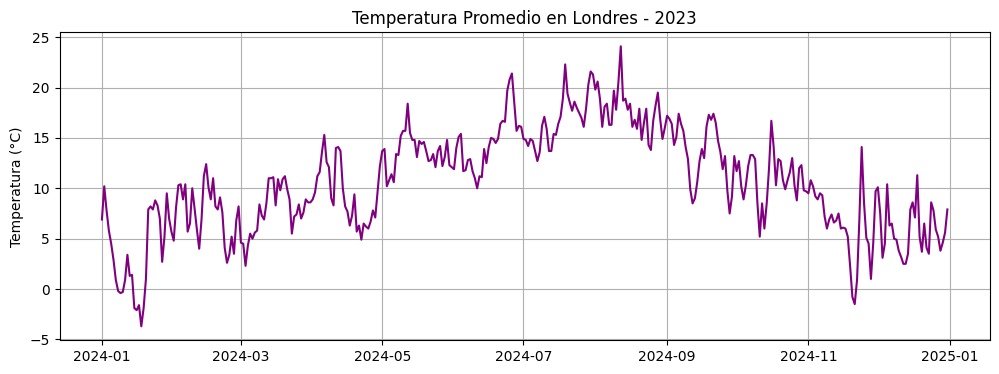


Entrenando modelo LSTM para el clima de Londres...
RMSE para Londres (Modelo Independiente): 2.9349 °C


In [ ]:
# 1. Obtenemos datos de Londres para el año 2023
latitude  = 51.5074
longitude = -0.1278

POINT = ms.Point(latitude,longitude, 113)
START = date(2024, 1, 1)
END = date(2024, 12, 31)

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)

# Get daily data & perform interpolation
ts = ms.daily(stations, START, END)
data_london = ms.interpolate(ts, POINT).fetch()

# Limpiamos nulos
data_london = data_london.dropna(subset=['temp'])

# 2. Visualización rápida de la estacionalidad de Londres
plt.figure(figsize=(12, 4))
plt.plot(data_london.index, data_london['temp'], color='purple')
plt.title('Temperatura Promedio en Londres - 2023')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

# 3. Aplicamos el Pipeline Base
london_tavg = data_london[['temp']].values
scaler_london = MinMaxScaler(feature_range=(0,1))
london_scaled = scaler_london.fit_transform(london_tavg)

X_london, y_london = create_sequences(london_scaled, 14)

train_sz_l = int(len(X_london) * 0.8)
X_l_t, y_l_t = X_london[:train_sz_l], y_london[:train_sz_l]
X_l_test, y_l_test = X_london[train_sz_l:], y_london[train_sz_l:]

print("\nEntrenando modelo LSTM para el clima de Londres...")
modelo_london = entrenar_modelo_lstm(X_l_t, y_l_t)

pred_l = scaler_london.inverse_transform(modelo_london.predict(X_l_test, verbose=0))
real_y_l = scaler_london.inverse_transform(y_l_test.reshape(-1, 1))

rmse_london = np.sqrt(mean_squared_error(real_y_l, pred_l))
print(f"RMSE para Londres (Modelo Independiente): {rmse_london:.4f} °C")

## Conclusión Final

Tras finalizar los ejercicios prácticos de modelado climático, podemos destacar las siguientes conclusiones fundamentales sobre el comportamiento de las redes recurrentes:

### 1. El Costo de la "Memoria a Largo Plazo" (Ejercicio 2)
*   **Resultados:** El modelo con una ventana corta (7 días) obtuvo un RMSE de **0.7529 °C**, superando al modelo con ventana larga (60 días) que obtuvo un RMSE de **0.8000 °C**.
*   **Análisis:** En meteorología (y muchas otras series de tiempo), el pasado inmediato es el mejor predictor del futuro a corto plazo. Al forzar a la red a mirar 60 días atrás para predecir el clima de mañana, introdujimos "ruido" estacional irrelevante que diluyó la importancia de las temperaturas de la última semana. Las LSTMs pueden recordar a largo plazo, pero eso no siempre significa que esa información sea útil para la predicción inmediata.

### 2. El Espejismo Numérico de los Modelos Multivariados (Ejercicio 3)
*   **Resultados:** Al agregar `tmin` y `tmax` a nuestro modelo de 14 días, el RMSE fue de **0.7567 °C**, virtualmente idéntico (e incluso ligeramente superior) al modelo univariado más simple.
*   **Análisis:** Intuitivamente, pensaríamos que "más datos = mejores predicciones". Sin embargo, en la zona geográfica original del dataset (Cartagena), la temperatura de hoy y mañana están tan altamente correlacionadas que la temperatura promedio es suficiente. Agregar `tmin` y `tmax` añadió complejidad computacional sin aportar nueva información discriminante (colinealidad), lo que explica por qué la red no logró reducir más el error subyacente.

### 3. La Realidad de la Generalización Geográfica (Ejercicio 5)
*   **Resultados:** Al aplicar nuestra metodología a la ciudad de **Londres**, el RMSE se disparó a **2.9349 °C**.
*   **Análisis:** Este resultado es la lección más importante del Deep Learning aplicado. Londres, a diferencia de localidades tropicales, tiene estaciones muy marcadas, frentes fríos repentinos y alta volatilidad diaria (varianza). Un margen de error de casi 3 grados demuestra que los modelos climáticos son hiper-locales. La arquitectura que sirve para un clima monótono es insuficiente para modelar el caos atmosférico de latitudes altas; aquí sí requeriríamos modelos más profundos, ventanas más ajustadas, y definitivamente un enfoque multivariado agresivo (incluyendo humedad, presión, épocas del año, etc.).

### Reflexión General
El modelado de series de tiempo es inherentemente desafiante. No basta con apilar capas LSTM; el éxito radica en entender qué cantidad de "pasado" es estadísticamente relevante para el "futuro", y aceptar que los patrones aprendidos en un contexto (geográfico, financiero o físico) raramente son transferibles de manera universal.

## 10. Referencias y Recursos

- [Meteostat Python Library](https://dev.meteostat.net/python/)
- [Keras LSTM documentation](https://keras.io/api/layers/recurrent_layers/lstm/)
- Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation.
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [06. RNN/LSTM Intro](./06_redes_recurrentes_rnn_lstm.ipynb)